<a href="https://colab.research.google.com/github/abcdon21/Deep-Learning-/blob/main/CarsDeepLearning_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# from google.colab import files
# uploaded= files.upload()

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df= pd.read_csv('cars.csv')
df

,Unnamed: 0,Manufacturer,Model,Sales_in_thousands,four_year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,152,Volvo,V40,3.545,NaN,Passenger,24.40,1.9,160.0,100.5,67.6,176.6,3.042,15.8,25.0,9/21/2011,66.498812
153,153,Volvo,S70,15.245,NaN,Passenger,27.50,2.4,168.0,104.9,69.3,185.9,3.208,17.9,25.0,11/24/2012,70.654495
154,154,Volvo,V70,17.531,NaN,Passenger,28.80,2.4,168.0,104.9,69.3,186.2,3.259,17.9,25.0,6/25/2011,71.155978
155,155,Volvo,C70,3.493,NaN,Passenger,45.50,2.3,236.0,104.9,71.5,185.7,3.601,18.5,23.0,4/26/2011,101.623357


DATA PREPROCESSING

In [8]:
df.info()  #data is perfect no need of cleaning

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              157 non-null    int64  
 1   Manufacturer            157 non-null    object 
 2   Model                   157 non-null    object 
 3   Sales_in_thousands      157 non-null    float64
 4   four_year_resale_value  121 non-null    float64
 5   Vehicle_type            157 non-null    object 
 6   Price_in_thousands      155 non-null    float64
 7   Engine_size             156 non-null    float64
 8   Horsepower              156 non-null    float64
 9   Wheelbase               156 non-null    float64
 10  Width                   156 non-null    float64
 11  Length                  156 non-null    float64
 12  Curb_weight             155 non-null    float64
 13  Fuel_capacity           156 non-null    float64
 14  Fuel_efficiency         154 non-null    fl

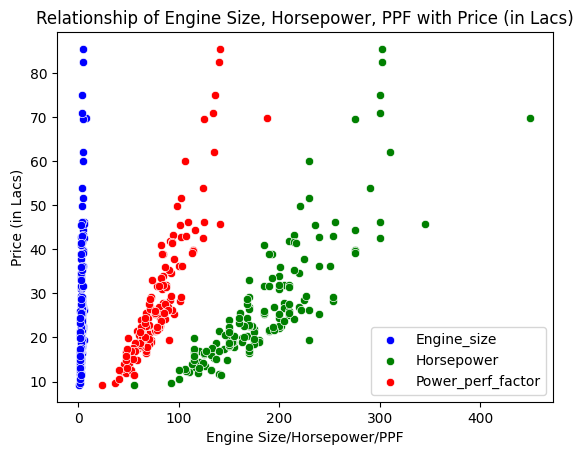

In [9]:
sns.scatterplot(x='Engine_size', y='Price_in_thousands', data=df, label='Engine_size', color='blue')
sns.scatterplot(x='Horsepower', y='Price_in_thousands', data=df, label='Horsepower', color='green')
sns.scatterplot(x='Power_perf_factor', y='Price_in_thousands', data=df, label='Power_perf_factor', color='red')

plt.xlabel('Engine Size/Horsepower/PPF')
plt.ylabel('Price (in Lacs)')

plt.title('Relationship of Engine Size, Horsepower, PPF with Price (in Lacs)')

plt.legend()
plt.show()

Feature encoding of vehicle type

In [10]:
df['Vehicle_type'].unique()

array(['Passenger', 'Car'], dtype=object)

In [11]:
df = pd.get_dummies(df, columns=['Vehicle_type'], drop_first=True)

In [12]:
df

,Unnamed: 0,Manufacturer,Model,Sales_in_thousands,four_year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor,Vehicle_type_Passenger
0,0,Acura,Integra,16.919,16.360,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150,True
1,1,Acura,TL,39.384,19.875,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778,True
2,2,Acura,CL,14.114,18.225,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN,True
3,3,Acura,RL,8.588,29.725,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779,True
4,4,Audi,A4,20.397,22.255,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,152,Volvo,V40,3.545,NaN,24.40,1.9,160.0,100.5,67.6,176.6,3.042,15.8,25.0,9/21/2011,66.498812,True
153,153,Volvo,S70,15.245,NaN,27.50,2.4,168.0,104.9,69.3,185.9,3.208,17.9,25.0,11/24/2012,70.654495,True
154,154,Volvo,V70,17.531,NaN,28.80,2.4,168.0,104.9,69.3,186.2,3.259,17.9,25.0,6/25/2011,71.155978,True
155,155,Volvo,C70,3.493,NaN,45.50,2.3,236.0,104.9,71.5,185.7,3.601,18.5,23.0,4/26/2011,101.623357,True


TRAIN TEST SPLIT

In [13]:
X = df.drop(['Manufacturer', 'Model', 'Unnamed: 0', 'Latest_Launch', 'four_year_resale_value'], axis = 1) #FEATURE
y = df['four_year_resale_value'] #TARGET
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

FEATURE SCALING

In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

NEURAL NETWORK

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input

In [16]:
model = Sequential() #OBJECT MAKING FOR NEURAL NETWORK

In [17]:
# Creating the Input Layer
model.add(Input(shape = (12,)))

# Creating the First Hidden Layer
model.add(Dense(1028, activation = 'relu'))

# Creating the Second Hidden Layer
model.add(Dense(512, activation = 'relu'))

# Creating the Third Hidden Layer
model.add(Dense(256, activation = 'relu'))

# Creating the Fourth Hidden Layer
model.add(Dense(128, activation = 'relu'))

# Creating the Output Layer
model.add(Dense(1, activation = 'linear'))

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1028)           │        13,364 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       526,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 704,565 (2.69 MB)

 Trainable params: 704,565 (2.69 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(loss = 'mse', metrics = ['r2_score'], optimizer = 'Adam')



In [20]:
model.fit(X_train, y_train, epochs = 100)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: nan - r2_score: nan
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: nan - r2_score: nan
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: nan - r2_score: nan
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: nan - r2_score: nan
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: nan - r2_score: nan
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: nan - r2_score: nan
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: nan - r2_score: nan
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: nan - r2_score: nan
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: nan - r2_score: nan
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: nan - r2_score: nan
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: nan - r2_score: nan
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: nan - r2_score: nan
Epoch 13/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: na

In [21]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


In [22]:
print(y_pred)

[[nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]
 [nan]]


In [23]:
model.layers[1].get_weights()

[array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], dtype=float32),
 array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
        nan, nan, nan, nan, nan, nan, nan, 